# ⚽ Football Analytics with Python
## Chapter 8 — Pizza Charts

**BarcaFutbol Analytics Course · HackrLife Media LLC**

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/HackrLife/Football-Analytics/blob/main/The-Football-Analytics-Course/Chapter-08-Pizza-Charts/Chapter_08_Pizza_Charts.ipynb)

---

A pizza chart is a radar chart's more practical sibling. Where a radar draws
a polygon across 6–8 metrics, a pizza chart uses wedge slices — one per metric
— that extend outward from a centre badge. It handles 10 or more metrics cleanly,
colour-codes each metric by its analytical category, and shows the player's
name and key stat in the centre circle.

Pizza charts are everywhere in football analytics publishing because they are
immediately understandable to non-technical readers. No one needs to be told
how to read a pizza — it looks like a pie chart, it reads like a percentage,
and the colour coding tells you immediately which metrics are strong (gold),
average (yellow), or weak (red).

### What You Will Build

1. **A single player pizza** — 10 metrics, coloured by category
2. **A dual pizza** — two players side by side for comparison
3. **The `build_pizza()` template** — any player, any 10 metrics

### The Key Difference from Radars

| Radar | Pizza |
|-------|-------|
| 4–8 metrics | 8–12 metrics |
| Polygon shape | Wedge slices |
| All same colour (per player) | Coloured by metric category |
| Shows player vs player | Shows player vs peer benchmark |
| Best for direct comparison | Best for complete profile view |

---
*Course GitHub: [github.com/HackrLife/Football-Analytics](https://github.com/HackrLife/Football-Analytics)*

In [1]:
!pip install pandas matplotlib numpy scipy --quiet
import pandas as pd, numpy as np, matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Wedge, Circle
from matplotlib.lines import Line2D
from scipy.interpolate import make_interp_spline
%matplotlib inline
plt.rcParams['figure.dpi'] = 150
print("✓ Ready.")

✓ Ready.


In [1]:
BG='#0d1117'; BG2='#0d1b2a'; BG3='#161b22'
WHITE='#f0f6fc'; GRAY='#8b949e'; GOLD='#EDBB00'
GREEN='#4CAF50'; YELLOW='#ffd60a'; ORANGE='#FF9800'; RED='#e63946'
TIER_COLORS={'Elite':GREEN,'Above Average':YELLOW,'Average':ORANGE,'Below Average':RED}
PLAYER_COLORS={
    'Marcus Silva':'#3498DB','Lucas Ferreira':'#2ecc71',
    'James Thornton':'#e74c3c','Diego Varela':'#9B59B6',
    'Amir Hassan':'#FF9800','Kai Becker':'#00BCD4',
    'Tom Wheeler':'#F06292','Sam Okafor':'#80CBC4',
    'Elena Rossi':'#FFD54F','Carlos Mendez':'#CE93D8',
    'Jin Park':'#A5D6A7',
}
def style_axis(ax,theme='dark',xlabel=None,ylabel=None,title=None,subtitle=None):
    bg=BG if theme=='dark' else '#f8f9fa'
    tc=WHITE if theme=='dark' else '#1a1a2e'
    gc=WHITE if theme=='dark' else '#cccccc'
    sc=GRAY  if theme=='dark' else '#888888'
    ax.set_facecolor(bg)
    ax.spines['bottom'].set_color(sc); ax.spines['left'].set_color(sc)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    ax.tick_params(colors=tc,labelsize=10)
    ax.grid(True,alpha=0.07,color=gc,linewidth=0.8)
    if xlabel: ax.set_xlabel(xlabel,color=tc,fontsize=11,labelpad=8)
    if ylabel: ax.set_ylabel(ylabel,color=tc,fontsize=11,labelpad=8)
    if title and subtitle:
        ax.set_title(title+'\n'+subtitle,color=tc,fontsize=13,fontweight='bold',pad=15,linespacing=1.6)
    elif title: ax.set_title(title,color=tc,fontsize=13,fontweight='bold',pad=12)
    return ax
print("✓ Design system loaded.")

✓ Design system loaded.


In [1]:
df = pd.read_csv('data/chapter08_players.csv')
print(df[['player','goals_per90','assists_per90','shots_per90','pass_accuracy_pct']].to_string(index=False))

        player  goals_per90  assists_per90  shots_per90  pass_accuracy_pct
  Marcus Silva         0.54           0.33         3.45               79.1
Lucas Ferreira         0.31           0.44         2.59               84.7
James Thornton         0.48           0.31         3.22               77.2
  Diego Varela         0.48           0.22         4.44               75.8
   Amir Hassan         0.34           0.43         2.51               86.4
    Kai Becker         0.35           0.29         3.01               81.3
   Tom Wheeler         0.31           0.45         2.93               82.6
    Sam Okafor         0.12           0.32         3.16               80.4
   Elena Rossi         0.29           0.23         3.38               76.9
 Carlos Mendez         0.50           0.22         3.77               74.3
      Jin Park         0.27           0.18         3.27               73.8


---
## Part 1 — The Wedge Geometry

A pizza chart is built from matplotlib `Wedge` patches. Each metric becomes one wedge of the circle. The wedge extends outward from the centre proportionally to the metric's normalised value.

```python
from matplotlib.patches import Wedge
Wedge(centre, radius, theta1, theta2, ...)
```
- `centre` — (x, y) position of the pizza centre, usually (0, 0)
- `radius` — how far the wedge extends. We use `0.28 + percentile * 0.60`
- `theta1`, `theta2` — start and end angle of the wedge in degrees

In [1]:
from matplotlib.patches import Wedge, Circle

# Define 10 metrics — (label, column, group_max, category)
PIZZA_METRICS = [
    ('Goals\n/90',    'goals_per90',      0.65, 'attacking'),
    ('xG\n/90',       'xg_per90',         0.50, 'attacking'),
    ('Assists\n/90',  'assists_per90',     0.55, 'attacking'),
    ('xA\n/90',       'xa_per90',         0.50, 'passing'),
    ('Key Pass\n/90', 'keyp_per90',       4.00, 'passing'),
    ('Pass Acc\n%',   'pass_accuracy_pct', 90.0, 'passing'),
    ('Shots\n/90',    'shots_per90',       5.00, 'attacking'),
    ('SOT\n/90',      'sot_per90',         2.00, 'attacking'),
    ('Dribbles\n/90', 'dribbles_per90',    8.00, 'attacking'),
    ('Tackles\n/90',  'tackles_per90',     2.50, 'defensive'),
]

# Colours by metric category
CATEGORY_COLORS = {
    'attacking': GOLD,      # gold = attacking metrics
    'passing':   GREEN,     # green = passing / creation metrics
    'defensive': '#3498DB', # blue = defensive metrics
}

# Show the wedge geometry for 10 metrics
n = len(PIZZA_METRICS)
degrees_per_wedge = 360 / n
print(f"10 metrics → {degrees_per_wedge:.1f}° per wedge")
print()
for i, (label, col, mx, cat) in enumerate(PIZZA_METRICS):
    t1 = 90 - i * degrees_per_wedge
    t2 = t1 - degrees_per_wedge
    print(f"  {label.replace(chr(10),' '):<15} θ1={t1:6.1f}° → θ2={t2:6.1f}°  category={cat}")

10 metrics → 36.0° per wedge

  Goals /90       θ1=  90.0° → θ2=  54.0°  category=attacking
  xG /90          θ1=  54.0° → θ2=  18.0°  category=attacking
  Assists /90     θ1=  18.0° → θ2= -18.0°  category=attacking
  xA /90          θ1= -18.0° → θ2= -54.0°  category=passing
  Key Pass /90    θ1= -54.0° → θ2= -90.0°  category=passing
  Pass Acc %      θ1= -90.0° → θ2=-126.0°  category=passing
  Shots /90       θ1=-126.0° → θ2=-162.0°  category=attacking
  SOT /90         θ1=-162.0° → θ2=-198.0°  category=attacking
  Dribbles /90    θ1=-198.0° → θ2=-234.0°  category=attacking
  Tackles /90     θ1=-234.0° → θ2=-270.0°  category=defensive


---
## Part 2 — Single Player Pizza

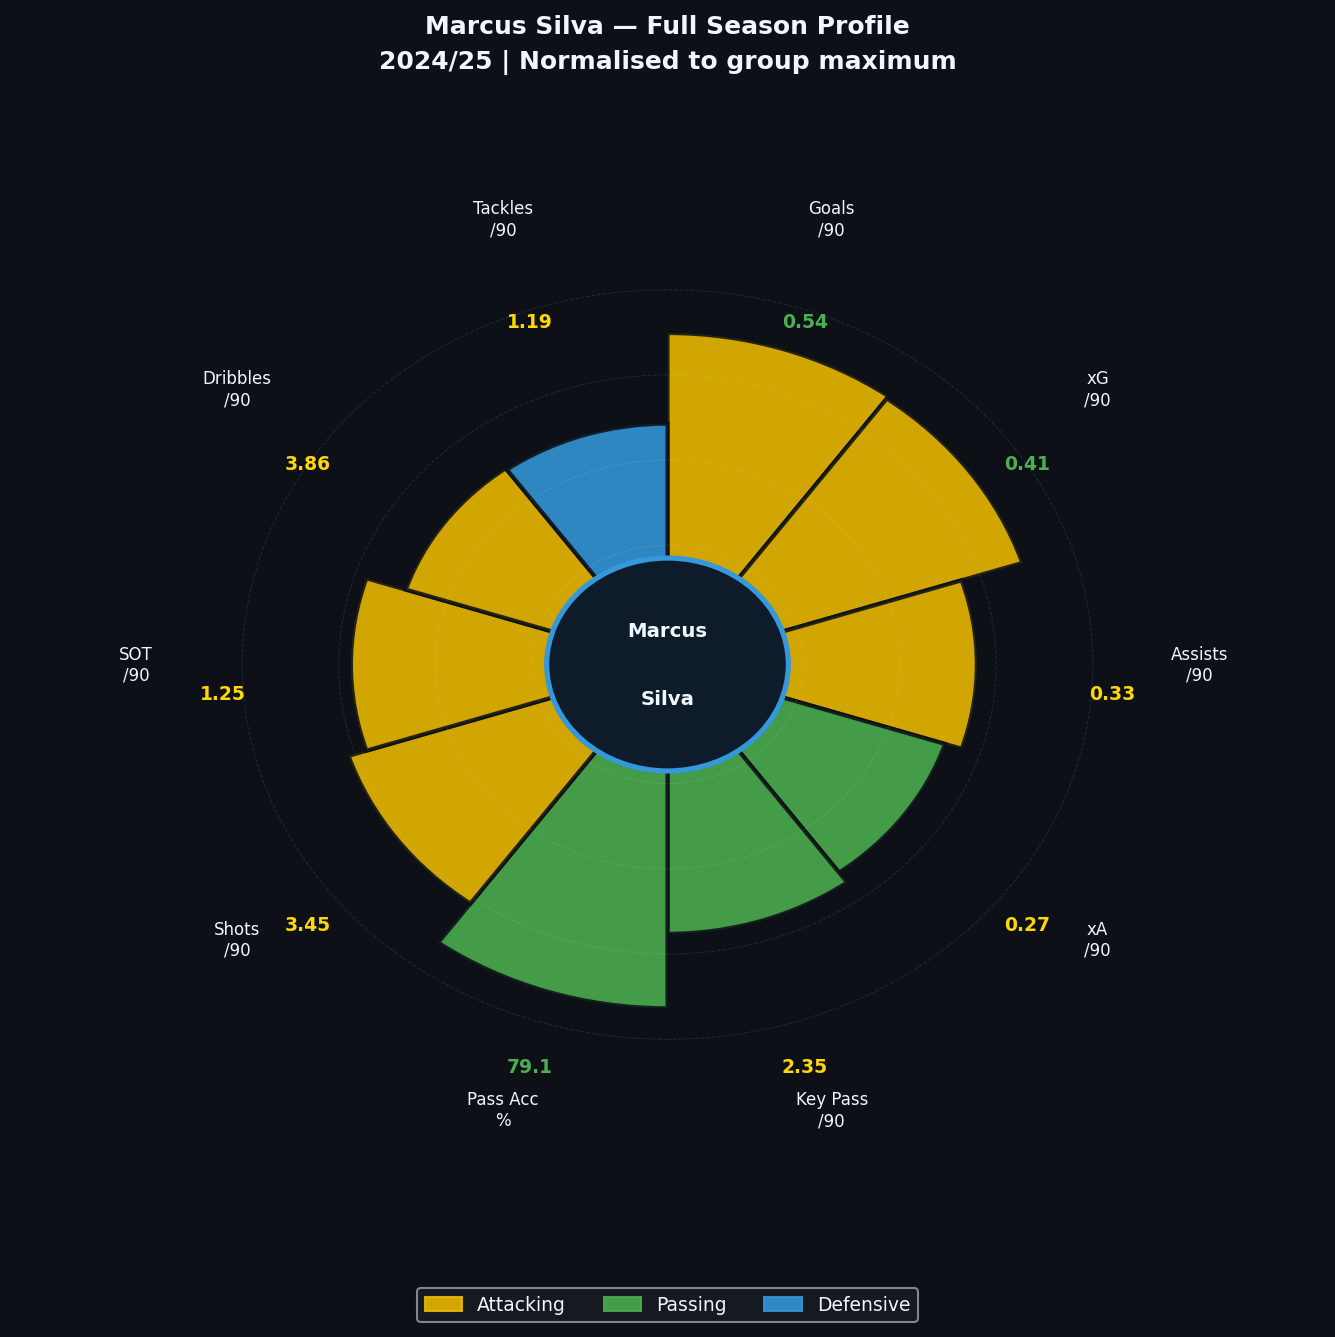

Reading the pizza:
  Gold wedges = attacking metrics (goals, xG, shots, dribbles)
  Green wedges = passing/creation metrics (assists, key passes, pass acc)
  Blue wedges = defensive metrics (tackles)
  Longer wedge = higher relative to group maximum
  Value label colour: green=strong, yellow=average, red=below average


In [1]:
def draw_pizza(ax, player, df, metrics=None, show_title=True):
    """
    Draw a pizza chart for a single player on the provided axes.

    Parameters
    ----------
    ax      : matplotlib Axes
    player  : str — player name
    df      : DataFrame containing player data
    metrics : list of (label, col, max, category) tuples
              (uses PIZZA_METRICS if None)
    """
    if metrics is None:
        metrics = PIZZA_METRICS

    row = df[df['player'] == player].iloc[0]
    n   = len(metrics)

    for i, (label, col, group_max, category) in enumerate(metrics):
        # Wedge angles — start at 90° (top) and go clockwise
        t1 = 90 - i * (360 / n)
        t2 = t1 - (360 / n)

        # Normalise the raw value to 0-1
        raw  = row[col]
        pct  = min(raw / group_max, 1.0)

        # Wedge radius: 0.28 (inner) to 0.88 (100th percentile)
        radius = 0.28 + pct * 0.60
        color  = CATEGORY_COLORS[category]

        ax.add_patch(Wedge((0, 0), r=radius,
                           theta1=t2, theta2=t1,
                           facecolor=color, edgecolor=BG,
                           linewidth=2, alpha=0.88))

        # Metric label (outside the wedge)
        angle_rad = np.radians((t1 + t2) / 2)
        ax.text(1.10 * np.cos(angle_rad), 1.10 * np.sin(angle_rad),
                label, ha='center', va='center',
                fontsize=8, color=WHITE, multialignment='center')

        # Value label (inside the wedge, coloured by tier)
        val_color = GREEN if pct >= 0.70 else (YELLOW if pct >= 0.40 else RED)
        display   = f'{raw:.2f}' if raw < 10 else f'{raw:.1f}'
        ax.text(0.92 * np.cos(angle_rad), 0.92 * np.sin(angle_rad) - 0.07,
                display, ha='center', va='center',
                fontsize=9, color=val_color, fontweight='bold')

    # Grid rings
    for r in [0.28, 0.48, 0.68, 0.88]:
        ax.add_patch(Circle((0,0), r, fill=False, color=WHITE,
                            alpha=0.10, linewidth=0.5, linestyle='--'))

    # Centre badge
    c = PLAYER_COLORS.get(player, GRAY)
    ax.add_patch(Circle((0, 0), 0.25, facecolor=BG2,
                         edgecolor=c, linewidth=2.5))
    name_parts = player.split()
    ax.text(0,  0.08, name_parts[0],  ha='center', va='center',
            fontsize=9.5, color=WHITE, fontweight='bold')
    ax.text(0, -0.08, name_parts[-1], ha='center', va='center',
            fontsize=9.5, color=WHITE, fontweight='bold')

    ax.set_xlim(-1.35, 1.35)
    ax.set_ylim(-1.35, 1.35)
    ax.axis('off')


# Draw Marcus Silva's pizza
fig, ax = plt.subplots(figsize=(9, 9))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)

draw_pizza(ax, 'Marcus Silva', df)

# Category legend
legend_patches = [mpatches.Patch(color=c, label=t.title(), alpha=0.88)
                  for t, c in CATEGORY_COLORS.items()]
ax.legend(handles=legend_patches, loc='lower center', ncol=3,
          facecolor=BG3, edgecolor=GRAY, labelcolor=WHITE,
          fontsize=9, framealpha=0.9, bbox_to_anchor=(0.5, -0.08))

ax.set_title('Marcus Silva — Full Season Profile\n'
             '2024/25 | Normalised to group maximum',
             color=WHITE, fontsize=12, fontweight='bold',
             pad=10, linespacing=1.6)

plt.tight_layout()
plt.show()

print("Reading the pizza:")
print("  Gold wedges = attacking metrics (goals, xG, shots, dribbles)")
print("  Green wedges = passing/creation metrics (assists, key passes, pass acc)")
print("  Blue wedges = defensive metrics (tackles)")
print("  Longer wedge = higher relative to group maximum")
print("  Value label colour: green=strong, yellow=average, red=below average")

---
## Part 3 — Dual Pizza: Two Players Side by Side

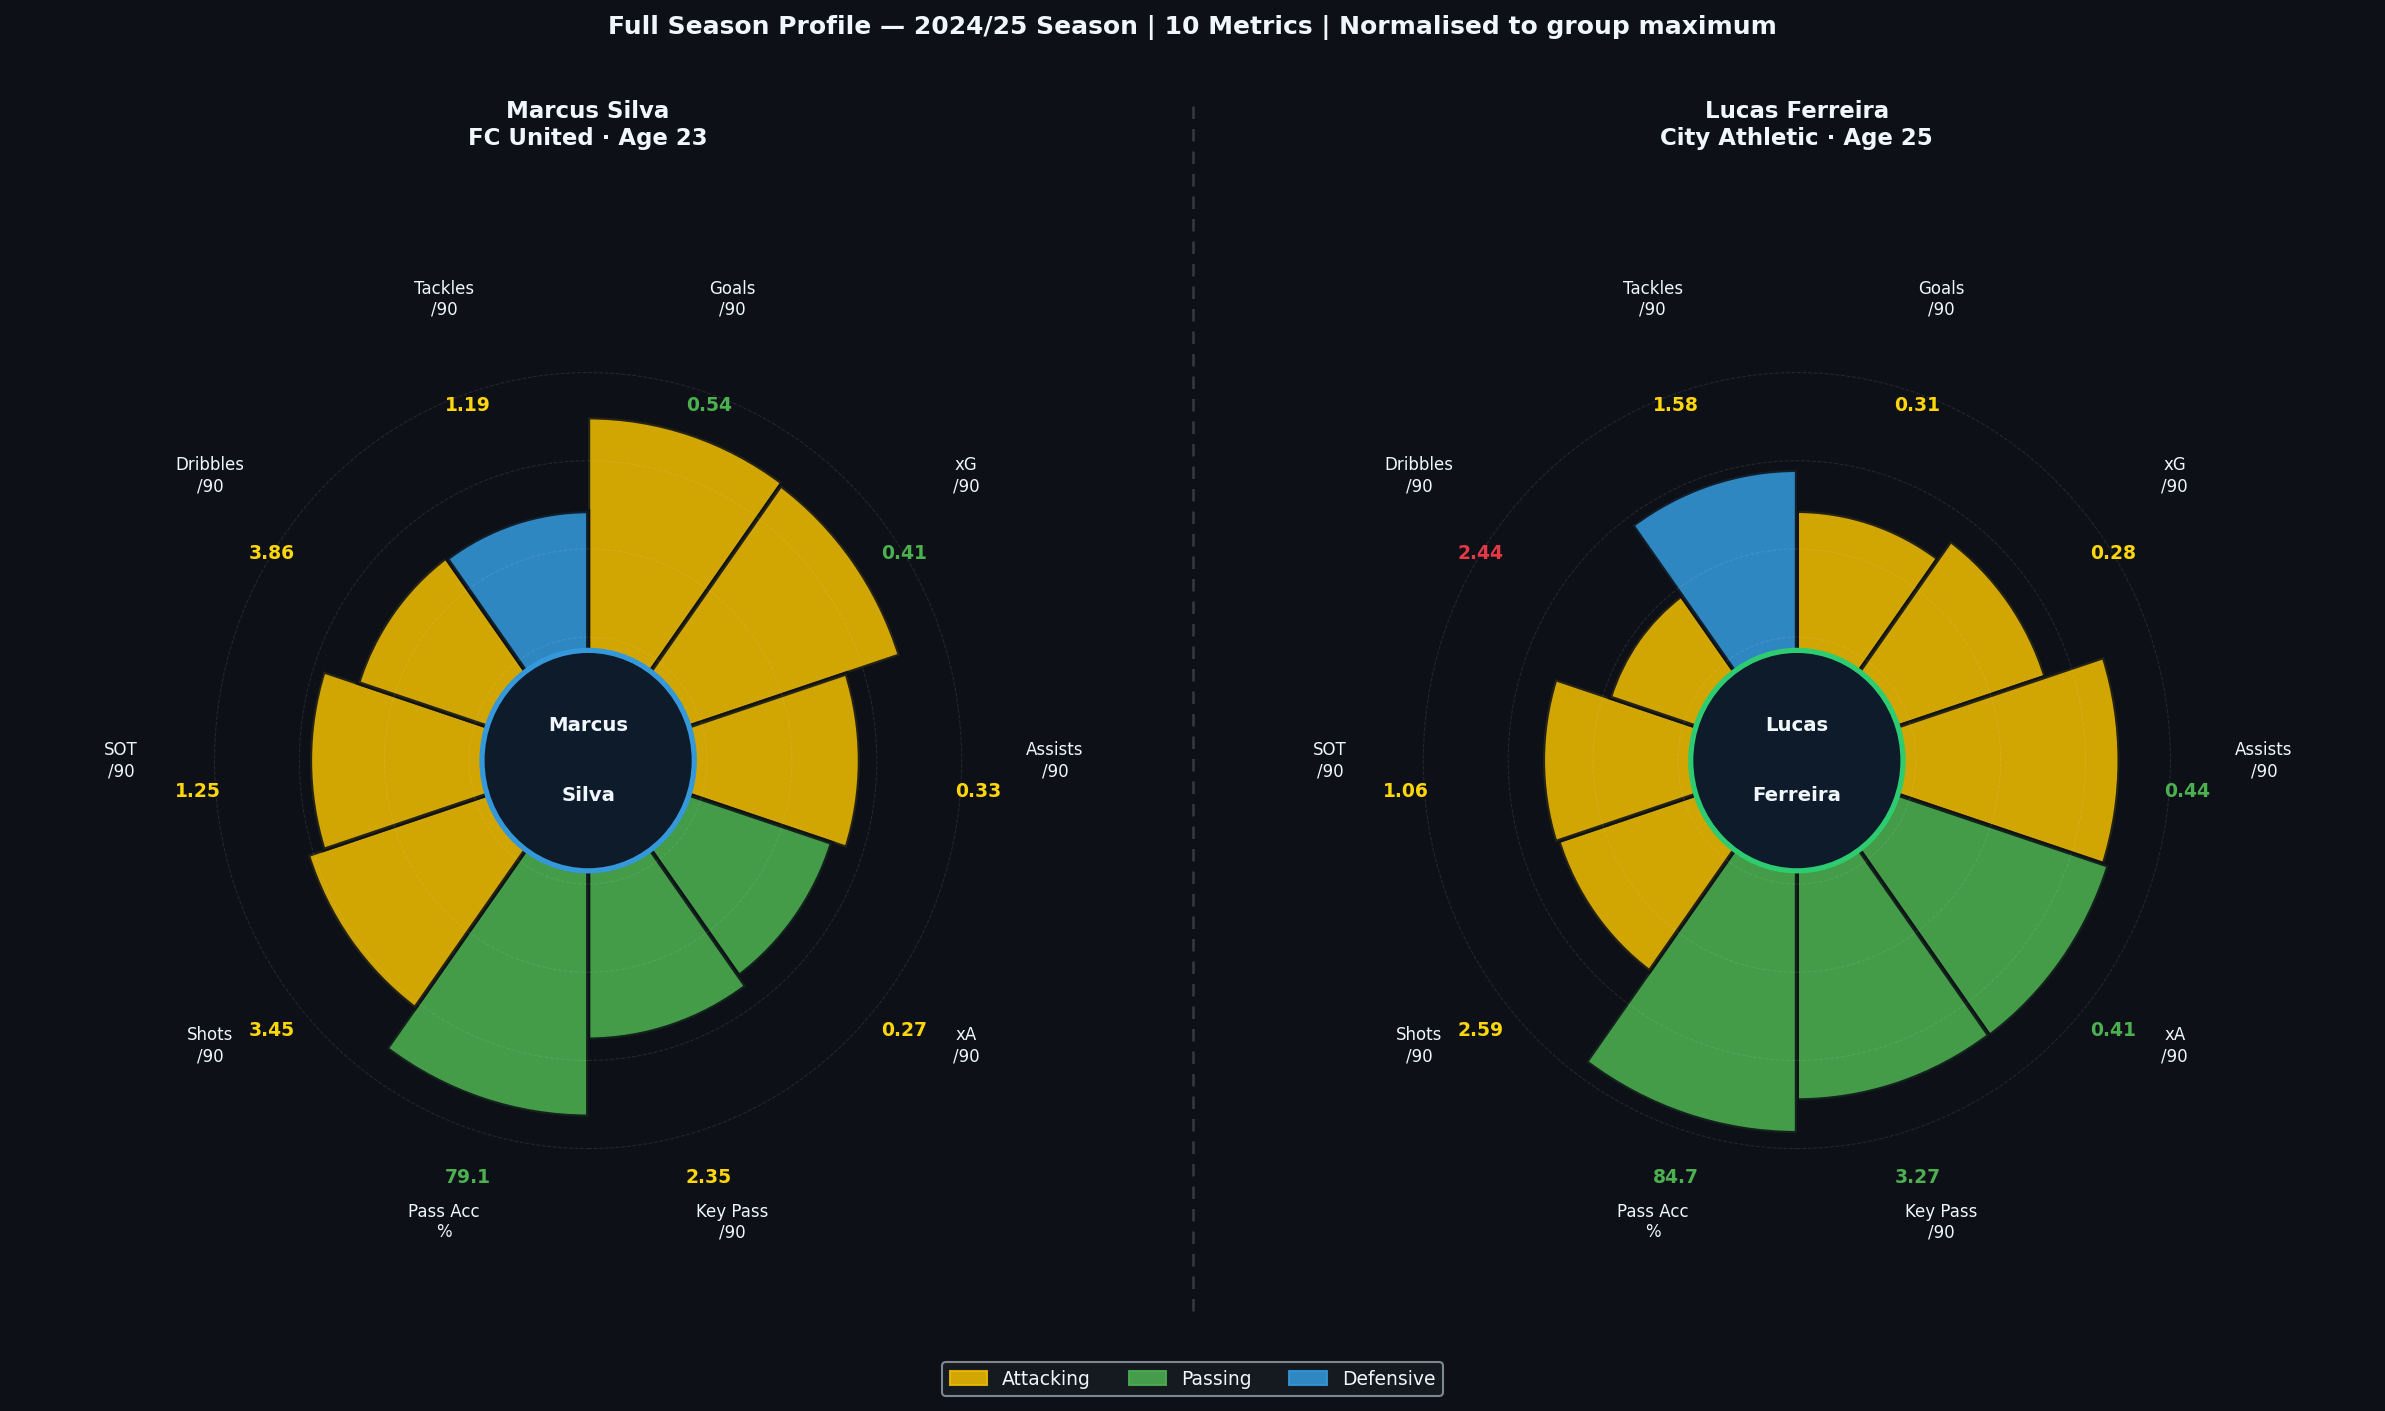

What the dual pizza shows in one glance:
  Marcus Silva:   longer attacking wedges (goals, shots, dribbles)
  Lucas Ferreira: longer passing wedges (assists, key passes, pass acc)
  Both have similar defensive contribution (short blue wedge)


In [1]:
def build_dual_pizza(df, player1, player2, metrics=None, figsize=(16, 9)):
    """
    Build two pizza charts side by side for player comparison.

    Parameters
    ----------
    df             : DataFrame
    player1        : str — left player
    player2        : str — right player
    metrics        : list of (label, col, max, category) tuples
    figsize        : tuple

    Returns: fig
    """
    if metrics is None:
        metrics = PIZZA_METRICS

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)
    fig.patch.set_facecolor(BG)
    ax1.set_facecolor(BG); ax2.set_facecolor(BG)

    draw_pizza(ax1, player1, df, metrics)
    draw_pizza(ax2, player2, df, metrics)

    # Divider line between the two charts
    fig.add_artist(plt.Line2D(
        [0.5, 0.5], [0.05, 0.95],
        transform=fig.transFigure,
        color=WHITE, alpha=0.18, linewidth=1.2, linestyle=(0, (5, 4))
    ))

    # Category legend at the bottom
    legend_patches = [mpatches.Patch(color=c, label=t.title(), alpha=0.88)
                      for t, c in CATEGORY_COLORS.items()]
    fig.legend(handles=legend_patches, loc='lower center', ncol=3, fontsize=9,
               facecolor=BG3, edgecolor=GRAY, labelcolor=WHITE,
               framealpha=0.9, bbox_to_anchor=(0.5, -0.02))

    fig.suptitle('Full Season Profile — 2024/25 | 10 Metrics | Normalised to group maximum',
                 color=WHITE, fontsize=12, fontweight='bold', y=1.01)

    plt.tight_layout(w_pad=3)
    return fig


# Build the dual pizza
fig = build_dual_pizza(df, 'Marcus Silva', 'Lucas Ferreira')
plt.show()

print("What the dual pizza shows in one glance:")
print("  Marcus Silva:   longer attacking wedges (goals, shots, dribbles)")
print("  Lucas Ferreira: longer passing wedges (assists, key passes, pass acc)")
print("  Both have similar defensive contribution (short blue wedge)")

---
## Exercises

### Exercise 1 (Easy) — Different Players
Call `build_dual_pizza(df, 'Diego Varela', 'Amir Hassan')`.
Which player has the more balanced profile? Which is more specialised?

### Exercise 2 (Medium) — Add a Fourth Category
Add a 'discipline' category for yellow cards. A player with fewer yellow cards
should score higher (invert the scale: higher cards = lower score).

```python
# In PIZZA_METRICS, add:
('YC
/90', 'tackles_per90', 2.5, 'discipline')  # placeholder — use yc column when available
CATEGORY_COLORS['discipline'] = '#E91E63'  # pink
```

### Exercise 3 (Hard) — Percentile Benchmarks
Instead of normalising to group maximum, normalise to the 95th percentile
of a larger population. This makes the pizza more meaningful — a wedge at 80%
means the player is at the 80th percentile of European wide forwards, not just
80% of this 11-player group.

---
## Chapter Summary

| Concept | What You Learned |
|---------|-----------------|
| `Wedge` patch | The building block of pizza charts |
| Wedge angles | `90 - i*(360/n)` for each metric |
| Wedge radius | `0.28 + percentile * 0.60` |
| Category colours | Gold=attacking, Green=passing, Blue=defensive |
| Centre badge | `Circle` patch with player name |
| `draw_pizza()` | Reusable single-player pizza function |
| `build_dual_pizza()` | Two pizzas side by side |

---
## Up Next — Chapter 9: Scatter Plots

*© 2026 HackrLife Media LLC · BarcaFutbol Analytics Course*